In [7]:
# fonction.py est resté à la racine du projet (partagé par tous les
# notebooks) : chaque notebook vivant maintenant dans son propre
# dossier, on ajoute le dossier parent au chemin d'import.
import sys, os
sys.path.append(os.path.abspath('..'))

from fonction import *

## Solution analytique de référence

L'EDP ∂u/∂t = D ∂²u/∂x² − αu, avec condition initiale gaussienne, admet la solution exacte suivante :

u(x, t) = (A / √(1 + 4Dt/σ²)) · exp(−(x − x0)² / (σ² + 4Dt)) · e^(−αt)

Cette solution est exacte sur ℝ. Restreinte à [−L, L], elle est aussi la solution exacte du problème borné avec conditions de Dirichlet non-homogènes u(±L, t) = u_exact(±L, t). Elle sert donc de référence quel que soit L : aucune hypothèse « u ≈ 0 aux bords » n'est nécessaire (elle serait d'ailleurs fausse pour D = 5, où √(4DT) = L).



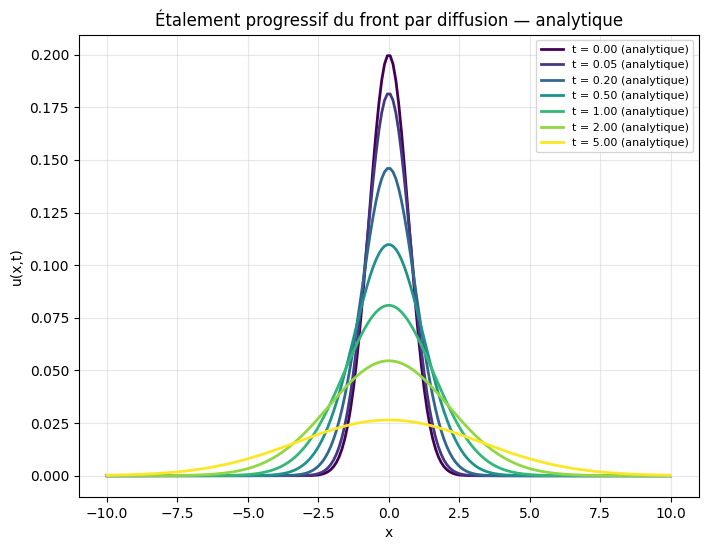

In [8]:


# --- Évaluation de la solution analytique sur une grille (x, t) -----------

Nt = 100
x_Analytique = np . linspace ( -L , L , Nx )
t = np . linspace (0 , T , Nt )

U = np.zeros (( Nt , Nx ) )
# Précalcul de toute la matrice U (comme avant, mais sans plt dans la boucle)
for i, ti in enumerate(t):
    U[i, :] = u_analytique(x_Analytique, ti, A, x0, sigma, D, alpha)

# --- Visualisation : étalement du choc à différents instants --------------

plt.style.use('default')
fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')
    
temps_a_tracer = [1e-4, 0.05, 0.2, 0.5, 1, 2, T]
colors = plt.cm.viridis(np.linspace(0, 1, len(temps_a_tracer)))

for k, (ti, c) in enumerate(zip(temps_a_tracer, colors)):
    
    ax.plot(x_Analytique, u_analytique(x_Analytique, ti, A,x0, sigma, D, alpha),
            color=c, linewidth=2, label=f"t = {ti:.2f} (analytique)")

ax.set_xlabel('x')
ax.set_ylabel('u(x,t)')
ax.set_title("Étalement progressif du front par diffusion — analytique")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.savefig('diffusion_analytique.png', dpi=300, bbox_inches='tight')
plt.show()

##  Résolution numérique par Volumes Finis

On discrétise le domaine en `Nx` cellules de taille dx et on intègre l'EDP sur
chaque volume de contrôle (cf. section 4 du sujet). Les flux diffusifs sont
approchés par différences finies, ce qui conduit au schéma explicite

u_i^{n+1} = u_i^n + r (u_{i+1}^n − 2u_i^n + u_{i-1}^n) − α Δt u_i^n,  avec r = DΔt/Δx²

Le pas de temps dt est fixé via le nombre de Courant `clf` pour respecter la
condition de stabilité r ≤ 1/2 (section 5 du sujet). Les bords sont traités par des conditions de Dirichlet non-homogènes : la valeur imposée est celle de la solution analytique, évaluée aux centres des cellules de bord. Ce choix permet la validation par solution exacte ; il n'a pas de sens physique en soi (dans un cas réel, la solution exacte est inconnue).

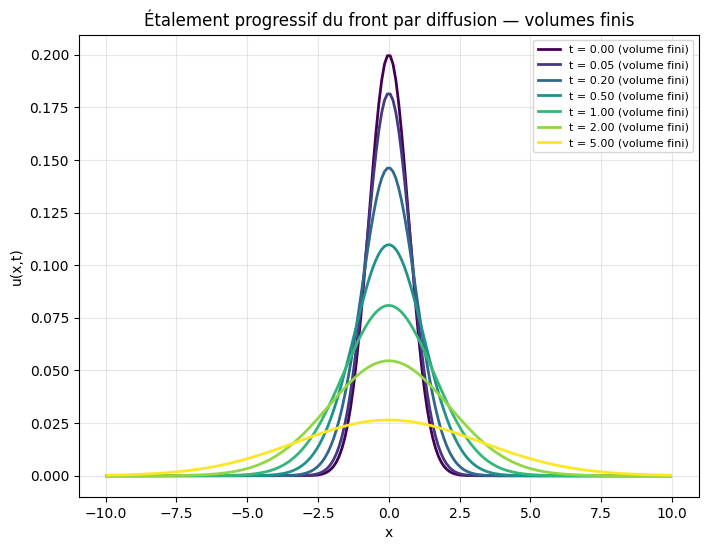

In [9]:


# --- Résolution avec les paramètres de référence --------------------------
x_VF, t_VF, U_num = u_volume_finie()


# --- Visualisation : solution numérique à différents instants -------------
plt.style.use('default')
fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')
    
temps_a_tracer = [1e-4, 0.05, 0.2, 0.5, 1, 2, T]
colors = plt.cm.viridis(np.linspace(0, 1, len(temps_a_tracer)))

for k, (ti, c) in enumerate(zip(temps_a_tracer, colors)):

    # Solution numérique (volumes finis) : étoiles rouges
    idx = np.argmin(np.abs(t_VF - ti))
    ax.plot(x_VF, U_num[idx, :], linewidth=2, label=f"t = {ti:.2f} (volume fini)", color=c, )

ax.set_xlabel('x')
ax.set_ylabel('u(x,t)')
ax.set_title("Étalement progressif du front par diffusion — volumes finis")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.savefig('diffusion_VF.png', dpi=300, bbox_inches='tight')
plt.show()

###  Superposition des deux solutions

On superpose la solution analytique (courbes) et la solution numérique
(étoiles rouges) aux mêmes instants, afin de vérifier visuellement que le
schéma Volumes Finis reproduit correctement la solution exacte (cf. section 6
du sujet : validation numérique).

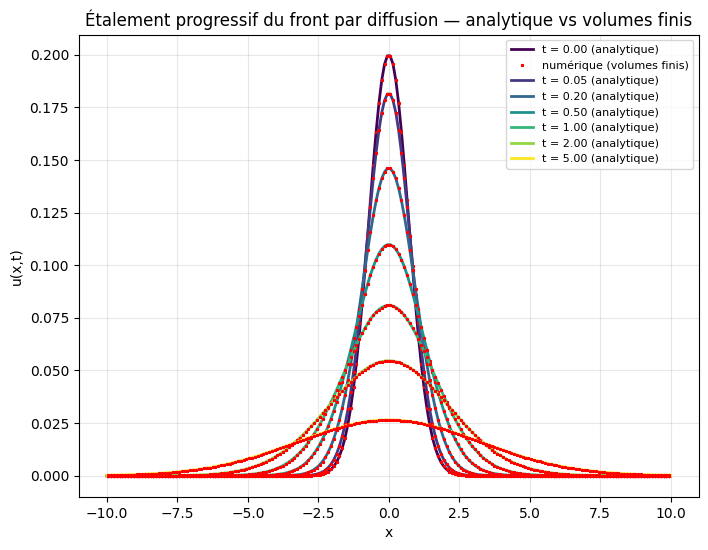

In [10]:
plt.style.use('default')
fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')
    
temps_a_tracer = [1e-4, 0.05, 0.2, 0.5, 1, 2, T]
colors = plt.cm.viridis(np.linspace(0, 1, len(temps_a_tracer)))

for k, (ti, c) in enumerate(zip(temps_a_tracer, colors)):
    # Solution analytique (couleur dégradée selon t)
    ax.plot(x_Analytique, u_analytique(x_Analytique, ti, A,x0, sigma, D, alpha),
            color=c, linewidth=2, label=f"t = {ti:.2f} (analytique)")

    # Solution numérique (volumes finis) : étoiles rouges
    idx = np.argmin(np.abs(t_VF - ti))
    ax.plot(x_VF, U_num[idx, :], color="red", marker='*', markersize=2,
             linestyle='none',
            label="numérique (volumes finis)" if k == 0 else None)

ax.set_xlabel('x')
ax.set_ylabel('u(x,t)')
ax.set_title("Étalement progressif du front par diffusion — analytique vs volumes finis")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.savefig('diffusion_analytique_vs_VF.png', dpi=300, bbox_inches='tight')
plt.show()

###  Quantification de l'erreur numérique

Pour valider objectivement le schéma Volumes Finis, on ne se contente pas
d'une comparaison visuelle : on calcule les erreurs L2 et L∞ entre la
solution numérique et la solution analytique, à un instant t donné
(cf. section 6 du sujet) :

L2 = √(Δx Σᵢ (u_num,i − u_exact,i)²)     
L∞ = maxᵢ |u_num,i − u_exact,i|

In [11]:

dx = x_VF[1] - x_VF[0]
# ------Exemple : erreur à t = 1.0-------
ti = 1.0
idx = np.argmin(np.abs(t_VF - ti))
U_exacte = u_analytique(x_VF, t_VF[idx], A, x0, sigma, D, alpha)
U_numerique = U_num[idx, :]

L2, Linf = erreurs_L2_Linf(x_VF, U_numerique, U_exacte, dx)
print(f"t = {ti:.2f}  |  L2 = {L2:.6f}  |  L∞ = {Linf:.6f}")

t = 1.00  |  L2 = 0.000094  |  L∞ = 0.000067


###  Évolution de l'erreur au cours de la simulation

L'erreur ponctuelle (à t = 1.0) ne suffit pas à juger de la qualité du schéma
sur toute la durée de la simulation. On calcule ici L2 et L∞ à **chaque**
instant simulé, pour voir si l'erreur reste bornée, croît, ou se stabilise
au cours du temps.

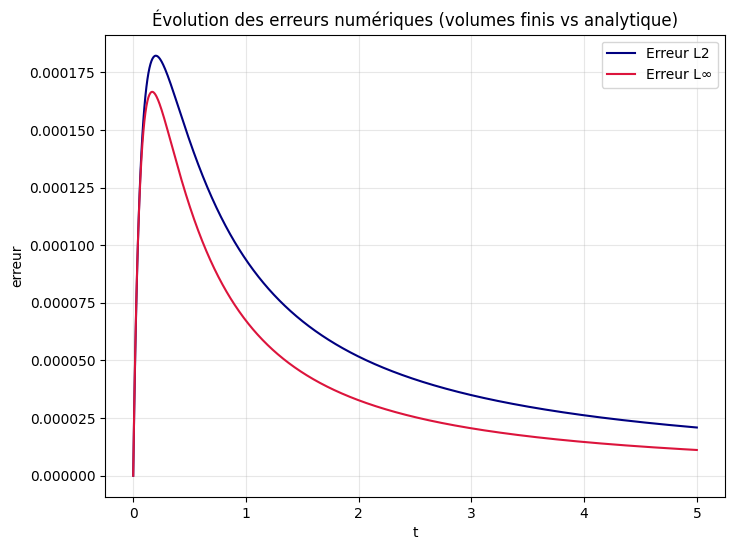

Erreur L2 max sur toute la simulation   : 0.000182
Erreur L∞ max sur toute la simulation   : 0.000167


In [12]:
L2_list = []
Linf_list = []

# --- Erreur à chaque instant simulé ----------------------------------------
for n in range(t_VF.size):
    U_exacte_n = u_analytique(x_VF, t_VF[n], A, x0, sigma, D, alpha)
    U_num_n = U_num[n, :]
    L2_n, Linf_n = erreurs_L2_Linf(x_VF, U_num_n, U_exacte_n, dx)
    L2_list.append(L2_n)
    Linf_list.append(Linf_n)

L2_list = np.array(L2_list)
Linf_list = np.array(Linf_list)

# --- Graphe de l'évolution des erreurs ---
plt.figure(figsize=(8, 6))
plt.plot(t_VF, L2_list, label="Erreur L2", color='navy')
plt.plot(t_VF, Linf_list, label="Erreur L∞", color='crimson')
plt.xlabel('t')
plt.ylabel('erreur')
plt.title("Évolution des erreurs numériques (volumes finis vs analytique)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('erreurs_numeriques.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Erreur L2 max sur toute la simulation   : {L2_list.max():.6f}")
print(f"Erreur L∞ max sur toute la simulation   : {Linf_list.max():.6f}")